In [ ]:
from google.colab import files
uploaded = files.upload();


Saving vegetables.jpeg to vegetables.jpeg


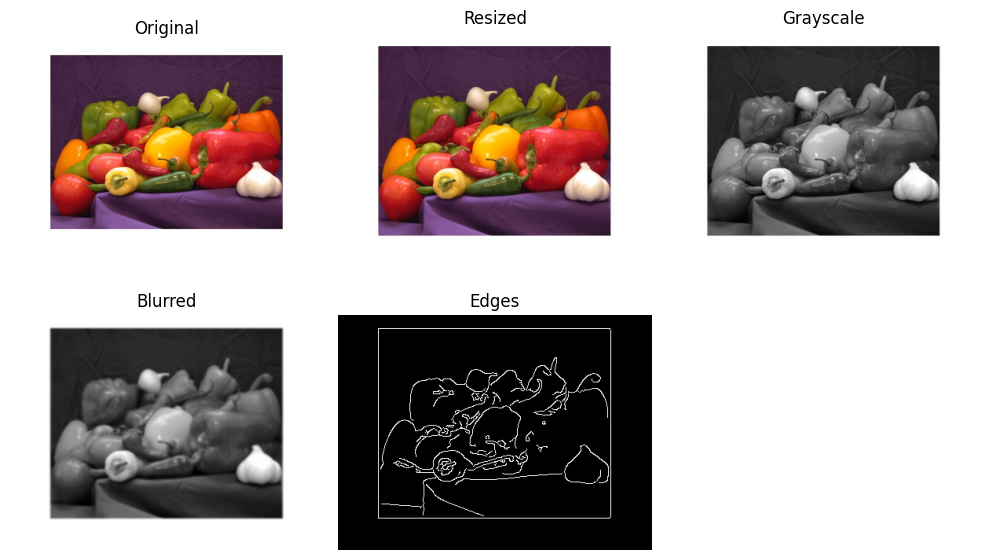

In [ ]:
import cv2                          # OpenCV for image processing
import matplotlib.pyplot as plt     # For displaying images


# 3️⃣ Read the image
image = cv2.imread("vegetables.jpeg")

# Check if image is loaded properly
if image is None:
    print("Error: Image not found. Check the path.")
    exit()

# Convert BGR (OpenCV default) to RGB for correct display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 4️⃣ Resize the image
resized = cv2.resize(image_rgb, (400, 300))

#we are converting to grayscale to reduce the dimensions


# 5️⃣ Convert to Grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)


# 6️⃣ Apply Gaussian Blur (Filtering)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 7️⃣ Edge Detection using Canny
edges = cv2.Canny(blur, 50, 150)

# 8️⃣ Display results
plt.figure(figsize=(10, 6))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Resized")
plt.imshow(resized)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Grayscale")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Blurred")
plt.imshow(blur, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Edges")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


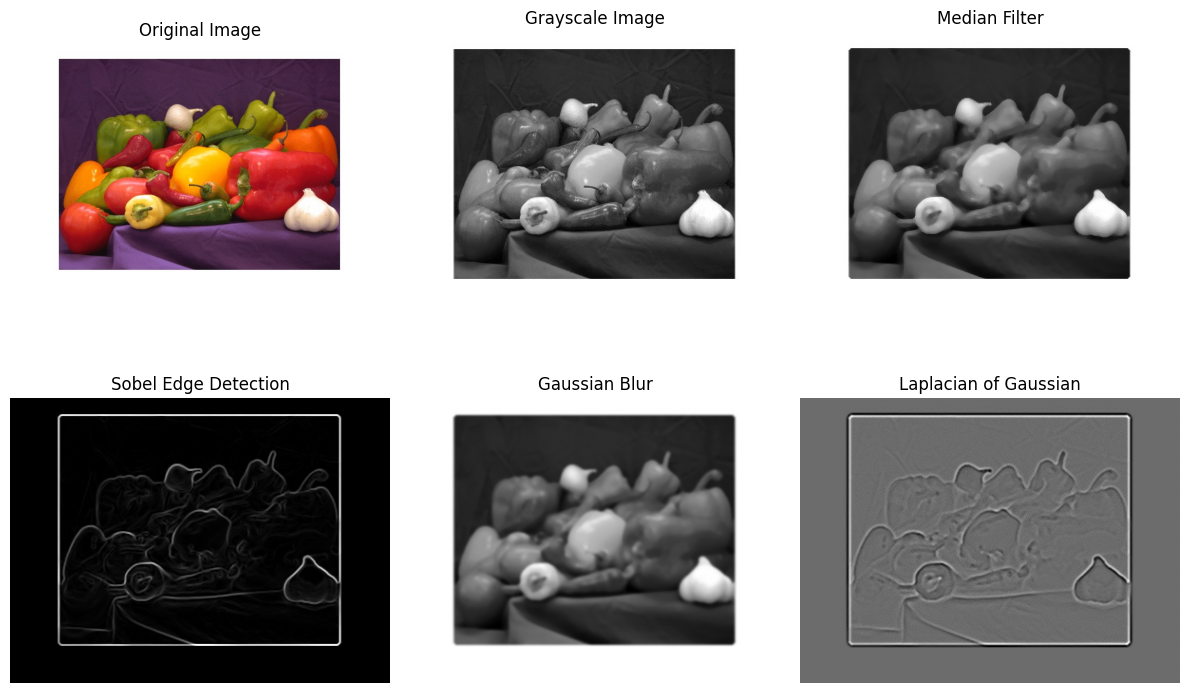

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1️⃣ Read the image
image = cv2.imread("vegetables.jpeg")

# Check if image loaded
if image is None:
    print("Error: Image not found")
    exit()

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image
resized = cv2.resize(image_rgb, (400, 300))

# Convert to Grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

# ----------------------------------
# 2️⃣ Median Filter (Noise Removal)
# ----------------------------------
median = cv2.medianBlur(gray, 5)

# ----------------------------------
# 3️⃣ Sobel Operator (Edge Detection)
# ----------------------------------
sobel_x = cv2.Sobel(median, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(median, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x, sobel_y)

# ----------------------------------
# 4️⃣ Laplacian of Gaussian (LoG)
# ----------------------------------
gaussian = cv2.GaussianBlur(median, (5, 5), 0)
log = cv2.Laplacian(gaussian, cv2.CV_64F)

# ----------------------------------
# 5️⃣ Display Results
# ----------------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Median Filter")
plt.imshow(median, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Sobel Edge Detection")
plt.imshow(sobel, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Gaussian Blur")
plt.imshow(gaussian, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Laplacian of Gaussian")
plt.imshow(log, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload();

Saving car.jpeg to car.jpeg


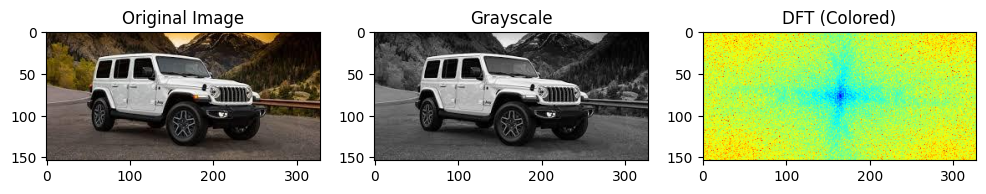

In [ ]:
# DFT
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("car.jpeg")   # car image path
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply DFT (converting the image into the frequency domain)
dft = cv2.dft(np.float32(gray), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# Compute magnitude spectrum
magnitude = cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1])
magnitude = np.log(magnitude + 1)

# Normalize
magnitude_norm = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
magnitude_norm = np.uint8(magnitude_norm)

# Convert grayscale output to colored image
colored_dft = cv2.applyColorMap(magnitude_norm, cv2.COLORMAP_JET)

# Display
plt.figure(figsize=(12,4))
plt.subplot(1,3,1), plt.imshow(img_rgb), plt.title("Original Image")
plt.subplot(1,3,2), plt.imshow(gray, cmap='gray'), plt.title("Grayscale")
plt.subplot(1,3,3), plt.imshow(colored_dft), plt.title("DFT (Colored)")
plt.show()


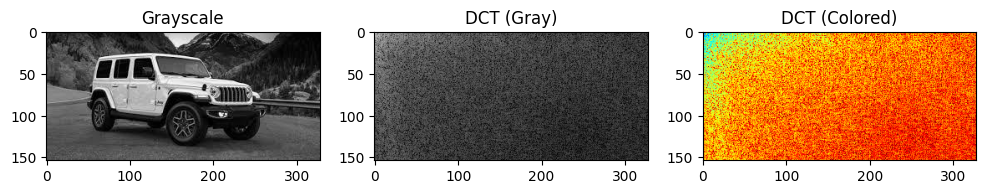

In [ ]:
#DCT
# Convert grayscale to float32
gray_float = np.float32(gray)

# Apply DCT
dct = cv2.dct(gray_float)

# Take log magnitude
dct_log = np.log(np.abs(dct) + 1)

# Normalize
dct_norm = cv2.normalize(dct_log, None, 0, 255, cv2.NORM_MINMAX)
dct_norm = np.uint8(dct_norm)

# Convert grayscale output to colored image
colored_dct = cv2.applyColorMap(dct_norm, cv2.COLORMAP_JET)

# Display
plt.figure(figsize=(12,4))
plt.subplot(1,3,1), plt.imshow(gray, cmap='gray'), plt.title("Grayscale")
plt.subplot(1,3,2), plt.imshow(dct_norm, cmap='gray'), plt.title("DCT (Gray)")
plt.subplot(1,3,3), plt.imshow(colored_dct), plt.title("DCT (Colored)")
plt.show()